In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from transformers import AutoTokenizer, AutoModel
from Bio.Align import substitution_matrices
import torch
import os
import time
import warnings
warnings.filterwarnings("ignore")



In [8]:
X_test = np.load("../data/X_test.npy")
y_test = np.load("../data/y_test.npy")
test_sequences = np.load("../data/test_sequences.npy", allow_pickle=True)
clf = joblib.load("../models/lr_classifier.pkl")

In [9]:
### ESM model
MODEL_NAME = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
esm2 = AutoModel.from_pretrained(MODEL_NAME)
esm2.eval()

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


EsmModel(
  (embeddings): EsmEmbeddings(
    (word_embeddings): Embedding(33, 320, padding_idx=1)
    (dropout): Dropout(p=0.0, inplace=False)
    (position_embeddings): Embedding(1026, 320, padding_idx=1)
  )
  (encoder): EsmEncoder(
    (layer): ModuleList(
      (0-5): 6 x EsmLayer(
        (attention): EsmAttention(
          (self): EsmSelfAttention(
            (query): Linear(in_features=320, out_features=320, bias=True)
            (key): Linear(in_features=320, out_features=320, bias=True)
            (value): Linear(in_features=320, out_features=320, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (rotary_embeddings): RotaryEmbedding()
          )
          (output): EsmSelfOutput(
            (dense): Linear(in_features=320, out_features=320, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (LayerNorm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
        )
        (intermediate): EsmIntermediate(
    

In [21]:
def get_esm_embedding(seq):
    inputs = tokenizer(seq, return_tensors="pt",truncation=True, max_length=128)
    with torch.no_grad():
        out = esm2(**inputs)
    mask   = inputs["attention_mask"].unsqueeze(-1).float()
    summed = (out.last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return (summed / counts).numpy()

def get_amp_prob(seq):
    esm_embding = get_esm_embedding(seq)
    prob = clf.predict_proba(esm_embding)[0,1]
    return prob

In [22]:
### Attack
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def greedy_attack(seq, max_k=3):
    seq_list = list(seq)
    positions = list()
    substitutions = list()
    probs = [get_amp_prob(seq)]

    for _ in range(max_k):
        best_prob = probs[-1]
        best_pos, best_aa = None, None

        for i, orig_aa in enumerate(seq_list):
            for aa in AMINO_ACIDS:
                if aa == orig_aa:
                    continue
                candidate = seq_list[:i] + [aa] + seq_list[i+1:]
                p = get_amp_prob("".join(candidate))
                if p < best_prob:
                    best_prob = p
                    best_pos, best_aa = i, aa

        if best_pos is None:
            break
        positions.append(best_pos)
        substitutions.append((seq_list[best_pos], best_aa))
        seq_list[best_pos] = best_aa
        probs.append(best_prob)
        if best_prob <= 0.5:
            break   # prediction flipped — attack succeeded
    adv_seq_info =  {
                    "adv_seq"        : "".join(seq_list),
                    "n_mutations"    : len(positions),
                    "positions"      : positions,
                    "substitutions"  : substitutions,
                    "prob_trajectory": probs,
                    "flipped"        : probs[-1] <= 0.5,
                    }

    return adv_seq_info




#### Attack on the True-positive test amps

In [35]:
y_pred = clf.predict(X_test)
tp_mask = (y_test == 1) & (y_pred == 1)
tp_seqs = test_sequences[tp_mask]
print(f"True positives in test set : {tp_mask.sum()}")

# tp_seqs = tp_seqs[:5]
results = list()
t0 = time.time()

for i, seq in enumerate(tp_seqs):
    res = greedy_attack(seq, max_k=3)
    res["original_seq"] = seq
    results.append(res)
    if (i + 1) % 10 == 0:
        print(f"  [{i+1:3d}/{len(tp_seqs)}]  elapsed={time.time()-t0:.0f}s")

print(f"\nDone. Total time: {time.time()-t0:.0f}s")



True positives in test set : 408
  [ 10/408]  elapsed=189s
  [ 20/408]  elapsed=435s
  [ 30/408]  elapsed=650s
  [ 40/408]  elapsed=883s
  [ 50/408]  elapsed=1115s
  [ 60/408]  elapsed=1245s
  [ 70/408]  elapsed=1488s
  [ 80/408]  elapsed=1659s
  [ 90/408]  elapsed=1832s
  [100/408]  elapsed=2010s
  [110/408]  elapsed=2182s
  [120/408]  elapsed=2337s
  [130/408]  elapsed=2517s
  [140/408]  elapsed=2719s
  [150/408]  elapsed=2870s
  [160/408]  elapsed=3050s
  [170/408]  elapsed=3236s
  [180/408]  elapsed=3411s
  [190/408]  elapsed=3564s
  [200/408]  elapsed=3799s
  [210/408]  elapsed=4035s
  [220/408]  elapsed=4263s
  [230/408]  elapsed=4494s
  [240/408]  elapsed=4692s
  [250/408]  elapsed=4922s
  [260/408]  elapsed=5191s
  [270/408]  elapsed=5383s
  [280/408]  elapsed=5527s
  [290/408]  elapsed=5694s
  [300/408]  elapsed=5854s
  [310/408]  elapsed=6095s
  [320/408]  elapsed=6221s
  [330/408]  elapsed=6398s
  [340/408]  elapsed=6550s
  [350/408]  elapsed=6752s
  [360/408]  elapsed=6873s

In [40]:
df_res = pd.DataFrame(results)

for k in [1, 2, 3]:
    success = df_res.apply(
        lambda r: r["flipped"] and r["n_mutations"] <= k, axis=1)
    print(f"ASR at k={k}: {success.mean()*100:.1f}%  ({success.sum()}/{len(df_res)})")

flipped_df = df_res[df_res["flipped"]]
mean_muts  = flipped_df["n_mutations"].mean() if len(flipped_df) > 0 else float("nan")
print(f"\nOverall flip rate : {df_res['flipped'].mean()*100:.1f}%")
print(f"Mean mutations to flip : {mean_muts:.2f}")
df_res.to_pickle("../data/attack_results.pkl")


ASR at k=1: 35.3%  (144/408)
ASR at k=2: 67.4%  (275/408)
ASR at k=3: 91.2%  (372/408)

Overall flip rate : 91.2%
Mean mutations to flip : 1.87


### BOLOSUM62 scores

In [41]:
df_res

,adv_seq,n_mutations,positions,substitutions,prob_trajectory,flipped,original_seq
0,MWSSIFFWLLLLVSLLVVIFRQWYAVADYCNRDADCKRVCLRPYAC...,3,"[7, 1, 22]","[(K, W), (K, W), (S, W)]","[0.8764103123478251, 0.7446969517742995, 0.512...",True,MKSSIFFKLLLLVSLLVVIFRQSYAVADYCNRDADCKRVCLRPYAC...
1,GIMSIVVDVDKNAAKEAAKGYLSTLSCKLAKTC,3,"[9, 20, 6]","[(A, D), (A, Y), (K, V)]","[0.9853038494196237, 0.9415125852597895, 0.682...",True,GIMSIVKDVAKNAAKEAAKGALSTLSCKLAKTC
2,MDTQLVVLIVALVFMQLFAQSEAFWSTIWNAAKSLIGKRGLRNLDD...,1,[1],"[(K, D)]","[0.654766265836881, 0.18671876295412948]",True,MKTQLVVLIVALVFMQLFAQSEAFWSTIWNAAKSLIGKRGLRNLDD...
3,MKFHLFFFILLFGATILTACKSYPEYGSLDLRKECKMRRGHYKLQY...,3,"[19, 41, 45]","[(K, C), (C, Y), (C, Y)]","[0.9405575755800747, 0.8588017299412405, 0.714...",True,MKFHLFFFILLFGATILTAKKSYPEYGSLDLRKECKMRRGHCKLQC...
4,MDILKKSLFLVLFLGLVSLSACEEEKRENEDEEKQEDDEQSEMKRA...,3,"[58, 20, 62]","[(A, D), (I, A), (G, C)]","[0.964267036165962, 0.8858511449617962, 0.7042...",True,MDILKKSLFLVLFLGLVSLSICEEEKRENEDEEKQEDDEQSEMKRA...
...,...,...,...,...,...,...,...
403,MSAQKIYLASLLLFICLVFPWSTVIVCNFEGHCVTSDDCINVCKSG...,2,"[23, 20]","[(A, V), (Q, W)]","[0.7827080512859427, 0.6200238993447987, 0.405...",True,MSAQKIYLASLLLFICLVFPQSTAIVCNFEGHCVTSDDCINVCKSG...
404,MKLLYDFDAILLAIEEPVISGKRHILRRMGNSGICRASCKKNEQPY...,2,"[7, 5]","[(L, D), (L, D)]","[0.8386171002584205, 0.5359322665611942, 0.276...",True,MKLLYLFLAILLAIEEPVISGKRHILRRMGNSGICRASCKKNEQPY...
405,MWFATCFLVSYVLVFLVLSVCKEVEAKELCNRIEDIDGNCDFEGEK...,2,"[1, 68]","[(K, W), (L, G)]","[0.7863687769868221, 0.6237799564782898, 0.438...",True,MKFATCFLVSYVLVFLVLSVCKEVEAKELCNRIEDIDGNCDFEGEK...
406,MKSITVICFLALCTVACTSKYPQEPVLADEARPFANSLFDELPEET...,2,"[16, 19]","[(I, C), (A, K)]","[0.835674664858612, 0.5810091760756217, 0.2962...",True,MKSITVICFLALCTVAITSAYPQEPVLADEARPFANSLFDELPEET...


In [42]:
blosum62 = substitution_matrices.load("BLOSUM62")

def blosum_score(old_aa, new_aa):
    try:
        return blosum62[old_aa, new_aa]
    except KeyError:
        return 0


all_subs = []
for _, row in flipped_df.iterrows():
    for old_aa, new_aa in row["substitutions"]:
        all_subs.append({
            "from"    : old_aa,
            "to"      : new_aa,
            "blosum62": blosum_score(old_aa, new_aa),
        })

df_subs = pd.DataFrame(all_subs)
print(f"Total substitutions : {len(df_subs)}")
print(f"Mean BLOSUM62 score : {df_subs['blosum62'].mean():.2f}")
print(f"% conservative (≥0) : {(df_subs['blosum62']>=0).mean()*100:.1f}%")


Total substitutions : 697
Mean BLOSUM62 score : -2.46
% conservative (≥0) : 3.4%


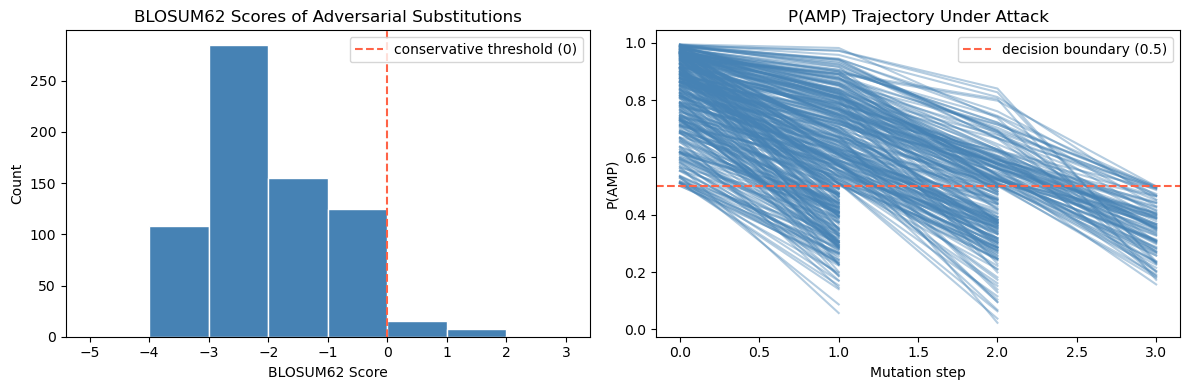

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bl_min = int(df_subs["blosum62"].min()) - 1
bl_max = int(df_subs["blosum62"].max()) + 2
axes[0].hist(df_subs["blosum62"], bins=range(bl_min, bl_max),
                color="steelblue", edgecolor="white")
axes[0].axvline(0, color="tomato", linestyle="--", label="conservative threshold (0)")
axes[0].legend()
axes[0].set_xlabel("BLOSUM62 Score")
axes[0].set_ylabel("Count")
axes[0].set_title("BLOSUM62 Scores of Adversarial Substitutions")

for _, row in flipped_df.iterrows():
    axes[1].plot(row["prob_trajectory"], alpha=0.4, color="steelblue")
axes[1].axhline(0.5, color="tomato", linestyle="--", label="decision boundary (0.5)")
axes[1].set_xlabel("Mutation step")
axes[1].set_ylabel("P(AMP)")
axes[1].set_title("P(AMP) Trajectory Under Attack")
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/figures/02_attack_results.png", dpi=150)
plt.show()
